# **WeatherWizard** project is designed to clean and prepare real world weather data. Forcast temprature, takes natural language inputs and translates them into temperature query actions. It provides users with up-to-date weather information

- Collins Emezie Ugwuozor
- [LinkedIn](https://www.linkedin.com/in/collins-ugwuozor)

In [1]:
import seaborn as sns
import ipywidgets as widgets
import matplotlib.pyplot as plt
from datetime import datetime, date
from IPython.display import display, clear_output
from ipywidgets import interact_manual, Text, DatePicker

from nlp import get_weather_info
from ml_model import fetch_weather_data
from ml_model import predict_temperature
from ml_model import train_temperature_model

import warnings
warnings.filterwarnings("ignore")

# EDA

## Steps:

### 1. **Data Collection**

Used Public weather dataset from [Open-meteo API](https://open-meteo.com/) to fetch weather data for the selected cities [`Lagos`, `Nairobi`, and `Cairo`].This API is favored for its data quality and does not require the creation of an API key. Environmental variables are not a concern for this project. 

### 2. **Data Cleaning**

* Handled missing values.forward filling adopted for this weather time series data
* Converted timestamps to datetime objects.
* Filtered data for the desired date range using `start_date` and `end_date`

### 3. **Exploratory Data Analysis (EDA)**

* **Seasonal Trends**: Used time series decomposition to identify seasonal patterns.
* **Outlier Detection**: Applied statistical method eg Z-score identify anomalies.
* **Feature Extraction**: Extracted key features such as Temperature (°C),Humidity (%),Pressure (hPa)',Wind Speed (m/s)',Precipitation (mm)',Cloud Cover (%),Solar Radiation (W/m²)

### 4. **Visualization**

* Ploted time series for each weather parameter.
* Created heatmaps for correlation analysis.
* Visualized seasonal patterns using line plots.

In [2]:
cities = ["Lagos", "Nairobi", "Cairo"]
start_date = "2023-01-01"
end_date = "2025-05-20"

In [3]:
df = fetch_weather_data(cities, start_date, end_date)

In [4]:
df.head()

,Datetime,Temperature (°C),Humidity (%),Pressure (hPa),Wind Speed (m/s),Wind Direction (°),Wind Gusts (m/s),Precipitation (mm),Cloud Cover (%),Solar Radiation (W/m²),City
0,2023-01-01 00:00:00,25.3,78,1010.5,6.1,208,9.4,0.0,0,0.0,Lagos
1,2023-01-01 01:00:00,24.1,77,1010.6,8.8,12,11.5,0.0,0,0.0,Lagos
2,2023-01-01 02:00:00,23.2,74,1010.1,11.2,356,17.3,0.0,0,0.0,Lagos
3,2023-01-01 03:00:00,22.4,62,1009.6,10.7,340,19.1,0.0,3,0.0,Lagos
4,2023-01-01 04:00:00,22.1,56,1009.3,8.9,346,16.9,0.0,15,0.0,Lagos


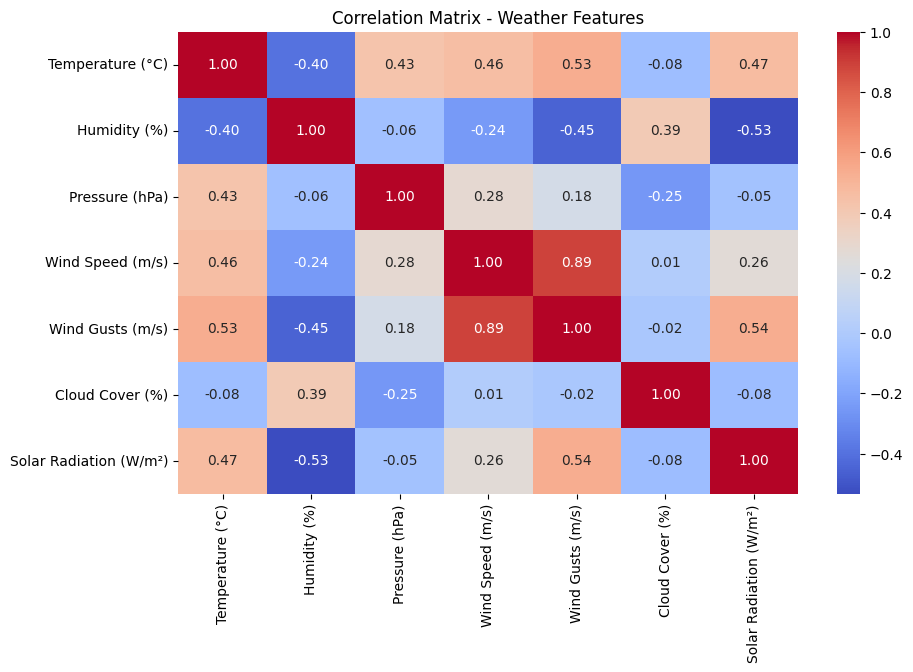

In [5]:
# Numeric weather features and their correlation with temprature
features = [
    'Temperature (°C)', 'Humidity (%)', 'Pressure (hPa)',
    'Wind Speed (m/s)', 'Wind Gusts (m/s)', 'Cloud Cover (%)', 'Solar Radiation (W/m²)'
]

# Correlation matrix
plt.figure(figsize=(10, 6))
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - Weather Features")
plt.show()

<Figure size 1000x700 with 0 Axes>

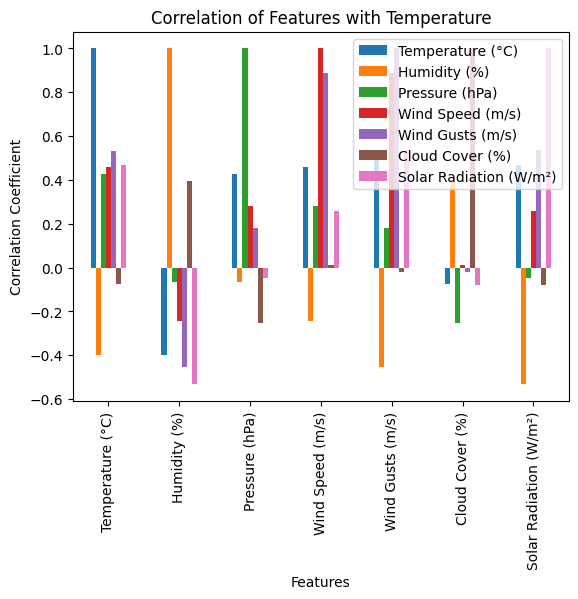

In [6]:
# Correlation of each feature with temperature
plt.figure(figsize=(10, 7))
corr.plot(kind='bar')
plt.title("Correlation of Features with Temperature")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=90)
plt.show()

### Insight on EDA Correlation
- Humidity and Cloud Cover negatively correlation with temperature (more cloud = less solar radiation = cooler).

- Solar Radiation shows a strong positive correlation with temperature — more sun = higher temps.

- Pressure changes shows weak correlation with temperature.

- Wind Speed slightly negatively correlates with temperature due to cooling effect (evaporation & mixing).

# Machine Learning

### Steps
- Used cities like Lagos, Nairobi and Cairo to train the model

- Used XGBoost (Gradient Boosted Trees) for forcasting. Why XGBoost

    - Handles non-linear relationships well

    - Robust to multicollinearity and missing values

    - Scalable and fast

    - Can incorporate multiple lagged features & exogenous variables (humidity, pressure, etc.)

- Implimented dynamic endpoint logic:
    - To decide endpoint: archive or forecast
    - To ensure fallback safety (e.g., skips city if geolocation fails or API returns no data).

- Predict next day's temperature up to 3 weeks ahead per city using previous
days' data(3 days lag).By using lagged features and daily summaries, I reduce overfitting.
- Takes only one city or uses training city data for prediction when wrong city is inputed.
- Implimented the DatePicker to ensures valid date input.

- A click on the `Run Interact` button triggers the prediction.

- The result will be shown as a table below the widget.

In [7]:
metrics = train_temperature_model(cities, start_date, end_date)

In [8]:
metrics['results']

,Date,City,target_temp,predicted_temp
1049,2023-12-16,Nairobi,19.258333,18.604252
1052,2023-12-17,Nairobi,19.495833,19.139328
1055,2023-12-18,Nairobi,19.287500,19.258860
1058,2023-12-19,Nairobi,19.295833,18.790203
1061,2023-12-20,Nairobi,19.445833,19.448099
...,...,...,...,...
2597,2025-05-15,Nairobi,18.762500,19.052254
2600,2025-05-16,Nairobi,18.779167,18.705946
2603,2025-05-17,Nairobi,18.545833,18.647848
2606,2025-05-18,Nairobi,18.579167,18.951969


In [9]:
print(f"RMSE: {metrics['rmse']}")
print(f"MAE: {metrics['mae']}")
print(f"R2 Score: {metrics['r2']}")

RMSE: 0.8427126797850061
MAE: 0.6579142772457345
R2 Score: 0.6741570978631721


In [10]:
# Make Prediction: Input Panel and Execution
@interact_manual(
    model_path=Text(value='xgb_temperature_model.joblib', description='Model Path:'),
    city=Text(value='Lagos', description='City:'),
    start_date=DatePicker(value=date(2025, 5, 24), description='Start Date:'),
    end_date=DatePicker(value=date(2025, 5, 30), description='End Date:')
)
def run_prediction(model_path, city, start_date, end_date):
    if start_date > end_date:
        print("Start date must be before end date.")
        return

    result_df = predict_temperature(model_path, city, start_date.isoformat(), end_date.isoformat())
    display(result_df)

interactive(children=(Text(value='xgb_temperature_model.joblib', continuous_update=False, description='Model P…

In [12]:
# Manually getting user inputs without using  ipywidgets
model_path = input("Enter model path (default: xgb_temperature_model.joblib): ") or "xgb_temperature_model.joblib"
city = input("Enter a city name: ")
start_date_str = input("Enter start date (YYYY-MM-DD): ")
end_date_str = input("Enter end date (YYYY-MM-DD): ")

# Convert string inputs to date objects
try:
    start_date = date.fromisoformat(start_date_str)
    end_date = date.fromisoformat(end_date_str)
    
    if start_date > end_date:
        print("Start date must be before end date.")
    else:
        # Run prediction
        result_df = predict_temperature(model_path, city, start_date.isoformat(), end_date.isoformat())
        print(result_df)
except ValueError:
    print("Invalid date format. Please enter dates in YYYY-MM-DD format.")

Enter model path (default: xgb_temperature_model.joblib):  
Enter a city name:  Lagos
Enter start date (YYYY-MM-DD):  2025-05-24
Enter end date (YYYY-MM-DD):  2025-05-30


         Date   City  predicted_temp
3  2025-05-27  Lagos       28.465754
4  2025-05-28  Lagos       28.044210
5  2025-05-29  Lagos       27.829575
6  2025-05-30  Lagos       27.666674


Things I would have done to enhance the model
- **RandomizedSearchCV:** for XGBoost (with TimeSeriesSplit)
- **Tune performance:** GridSearchCV or Optuna
- **Compare with ARIMA:** Univariate ARIMA baseline per city
- **Deep learning:** Use LSTM with sequence-to-sequence inputs
- **Stacking Ensemble (Meta-Model):** using ARIMA,XGBoost,LSTM as Base model, then train a Linear Regression or Ridge model as Meta Model.

# NLP

### Steps:
### Things I did to enhance the model
- Used `extract_info` function to get city, lon/lat and dates.
- Extract a city name from a text query using a simple named entity recognition (NER) approach
- Used the geopy library to get Latitude and longitude from the city.
- Converts dates to ISO format strings (YYYY-MM-DD) before API call.
- Fallback: manually scan for known city names if spaCy fails (e.g. Dakar)
- Start and end dates using the dateparser library. If only one date is found, it assigns it to both start_date and end_date.
- Handles errors gracefully with try/except.
- Parses and formats the daily weather data for display.

In [11]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# using Interactive widget interface to manually get user input
query_input = widgets.Text(
    value='',
    placeholder='Enter your weather query, e.g., "What will be the weather in Lagos for the next 4 days?" and hit Enter.',
    description='Query:',
    layout=widgets.Layout(width='90%')
)

# Create an output area
output = widgets.Output()

# Define what happens when Enter is pressed
def on_submit_enter(textbox):
    with output:
        clear_output()
        query = textbox.value.strip()
        if query:
            print("WeatherWizard is processing your query...\n")
            try:
                response = get_weather_info(query) 
                print(response)
            except NameError:
                print("Error: `get_weather_info` function is not defined. Please implement it.")

# Trigger on Enter key
query_input.observe(lambda change: on_submit_enter(query_input), names='value')

# Display the widgets
display(query_input, output)

Text(value='', description='Query:', layout=Layout(width='90%'), placeholder='Enter your weather query, e.g., …

Output()

In [13]:
# Manually getting user inputs without using  ipywidgets
def get_weather_query():
    """Prompt user for a weather query and fetch results."""
    query = input("Enter your weather query (e.g., 'Will it be hot in Dakar tomorrow?'): ").strip()

    if query:
        print("\nWeatherWizard is processing your query...\n")
        try:
            response = get_weather_info(query) 
            print(response)
        except NameError:
            print("Error: `get_weather_info` function is not defined. Please implement it.")
    else:
        print("No query entered. Please try again.")

# Run the weather query function
get_weather_query()

Enter your weather query (e.g., 'Will it be hot in Dakar tomorrow?'):  What will be the weather in Lagos next 4 days?



WeatherWizard is processing your query...

Weather in Lagos from 2025-05-25 to 2025-05-28:
  2025-05-25: Max 31.0°C, Min 26.8°C, Rain 3.5mm
  2025-05-26: Max 30.0°C, Min 27.4°C, Rain 1.7mm
  2025-05-27: Max 31.1°C, Min 27.4°C, Rain 0.5mm
  2025-05-28: Max 29.6°C, Min 27.1°C, Rain 12.9mm



### Things I would have done to enhance model
- world cities database (for broader detection) as a fallback if spaCy misses the city
- Add hourly data (e.g., temperature by hour).

- Cache results to avoid re-querying APIs.

- Handle vague phrases like “this weekend.”
- Offer suggestions for misspelled names (like "Lonodn")
- Use Agentic AI(langchain.agents) and call the `get_weather` functions  as a tool. see agentic_ai script for this implimentation